In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- نظرة أولية على البيانات ---
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4   

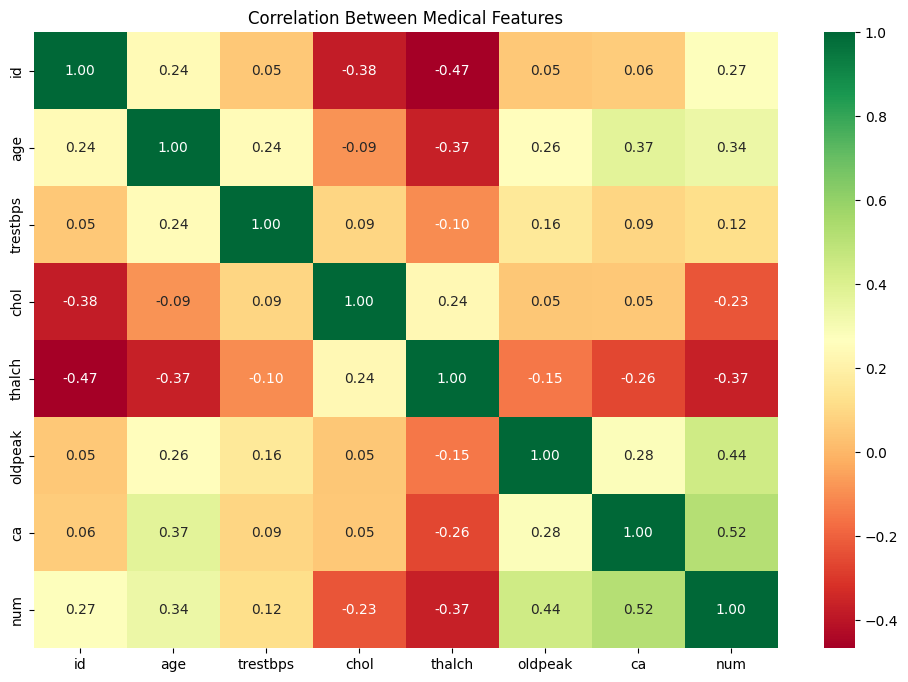

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Heart_Disease_AI/heart.csv.csv')

# 2. عرض أول 5 أسطر لفهم الأعمدة
print("--- نظرة أولية على البيانات ---")
print(df.head())

# 3. التأكد من عدم وجود بيانات مفقودة (Missing Values)
print("\n--- فحص البيانات المفقودة ---")
print(df.isnull().sum())

# 4. رسم خريطة الارتباط (Heatmap)
# لفهم أي العوامل (عمر، كوليسترول، إلخ) تؤثر أكثر على القلب
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation Between Medical Features")
plt.show()

KeyError: 'target'

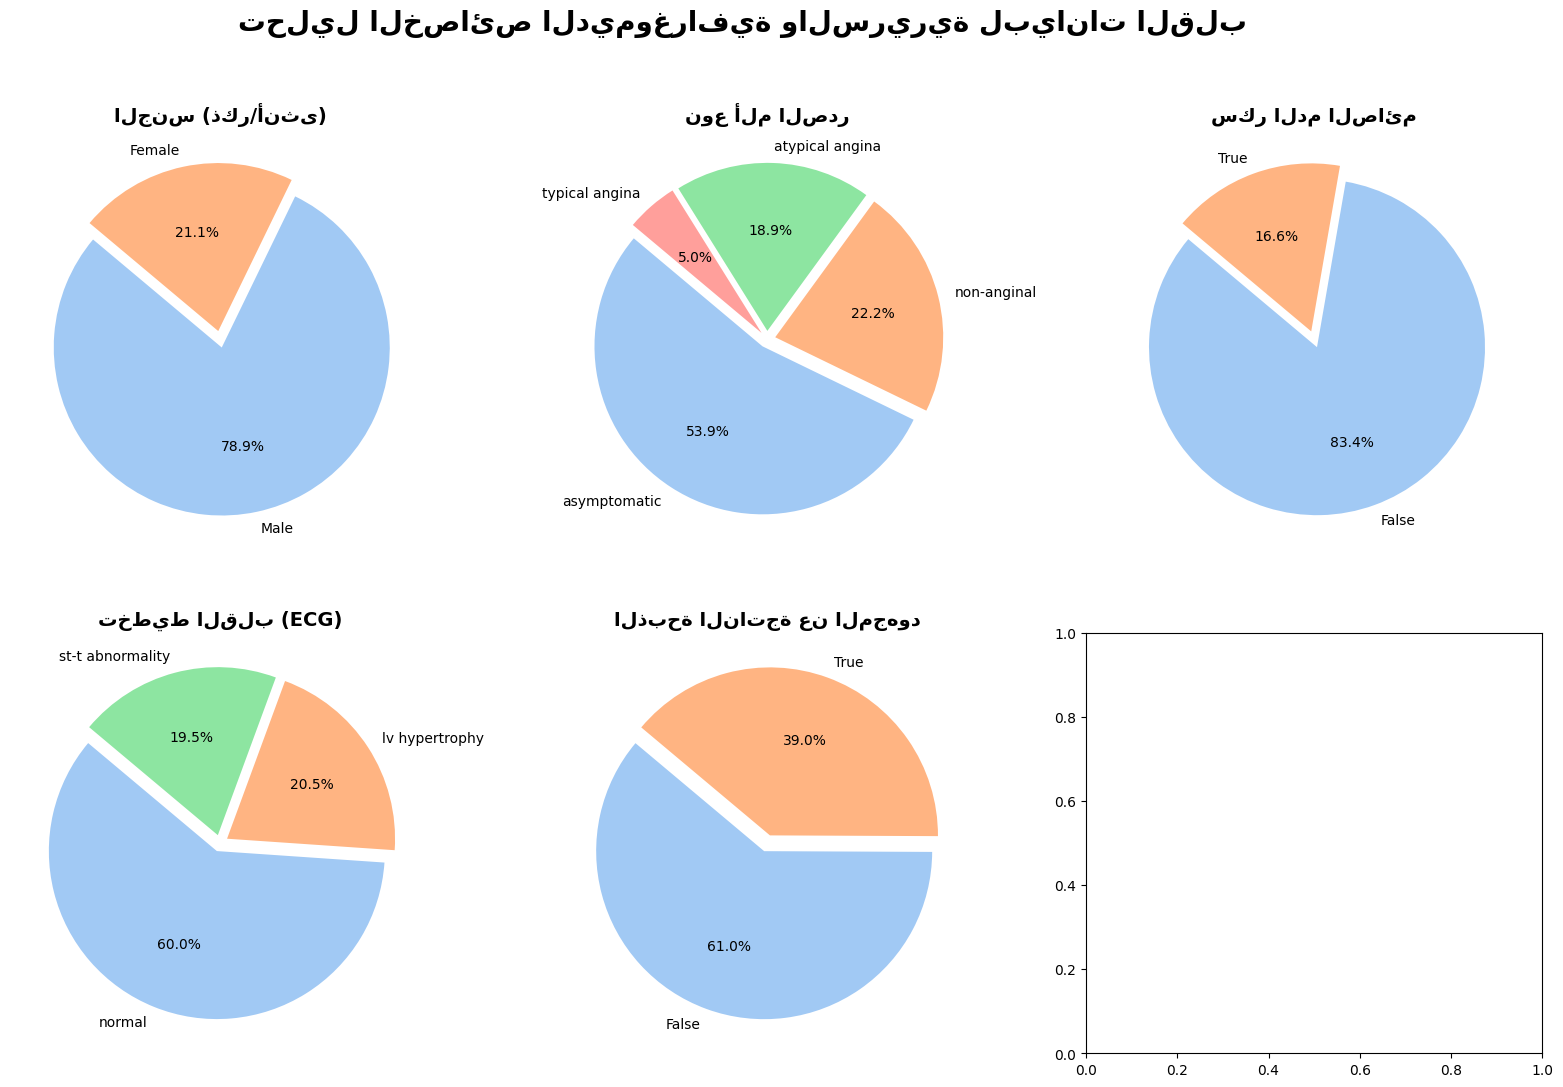

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# إعداد شكل الشبكة: صفين و3 أعمدة لعرض عدة خصائص مرة واحدة
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('تحليل الخصائص الديموغرافية والسريرية لبيانات القلب', fontsize=20, fontweight='bold')

# قائمة بالخصائص التي نريد تمثيلها دائرياً
features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'target']
titles = ['الجنس (ذكر/أنثى)', 'نوع ألم الصدر', 'سكر الدم الصائم',
          'تخطيط القلب (ECG)', 'الذبحة الناتجة عن المجهود', 'الحالة الصحية (الهدف)']

# الألوان المفضلة للرسوم
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

# حلقة تكرارية لإنشاء الرسوم تلقائياً في الـ subplots
for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    data = df[col].value_counts()
    ax.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140,
           colors=sns.color_palette('pastel'), explode=[0.05]*len(data))
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# 1. تعبئة القيم المفقودة في الأعمدة الرقمية بالوسيط (Median)
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. تعبئة القيم المفقودة في الأعمدة التصنيفية بالقيمة الأكثر تكراراً (Mode)
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. التأكد مرة أخرى من نظافة البيانات
print("\n--- فحص البيانات بعد التنظيف ---")
print(df.isnull().sum())

# 4. تحويل العمود المستهدف (num) إلى تصنيف ثنائي (0 أو 1)
# في هذه البيانات: 0 يعني سليم، وأي رقم آخر (1,2,3,4) يعني وجود إصابة
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# حذف الأعمدة التي لم نعد نحتاجها (مثل id والعمود القديم num)
df = df.drop(['id', 'dataset', 'num'], axis=1)

print("\nتم تجهيز البيانات بنجاح!")
print(df.head())


--- فحص البيانات بعد التنظيف ---
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

تم تجهيز البيانات بنجاح!
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak        slope   ca               thal  target  
0   150.0  False      2.3  downsloping  0.0       fixed defect       0  
1   108.0   True      1.5         flat  3.0             normal       1  
2   129.0   True      2.6        

/tmp/ipython-input-1737878069.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


/tmp/ipython-input-2075161494.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])



--- فحص البيانات بعد التنظيف ---
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

تم تجهيز البيانات بنجاح!
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak        slope   ca               thal  target  
0   150.0  False      2.3  downsloping  0.0       fixed defect       0  
1   108.0   True      1.5         flat  3.0             normal       1  
2   129.0   True      2.6        

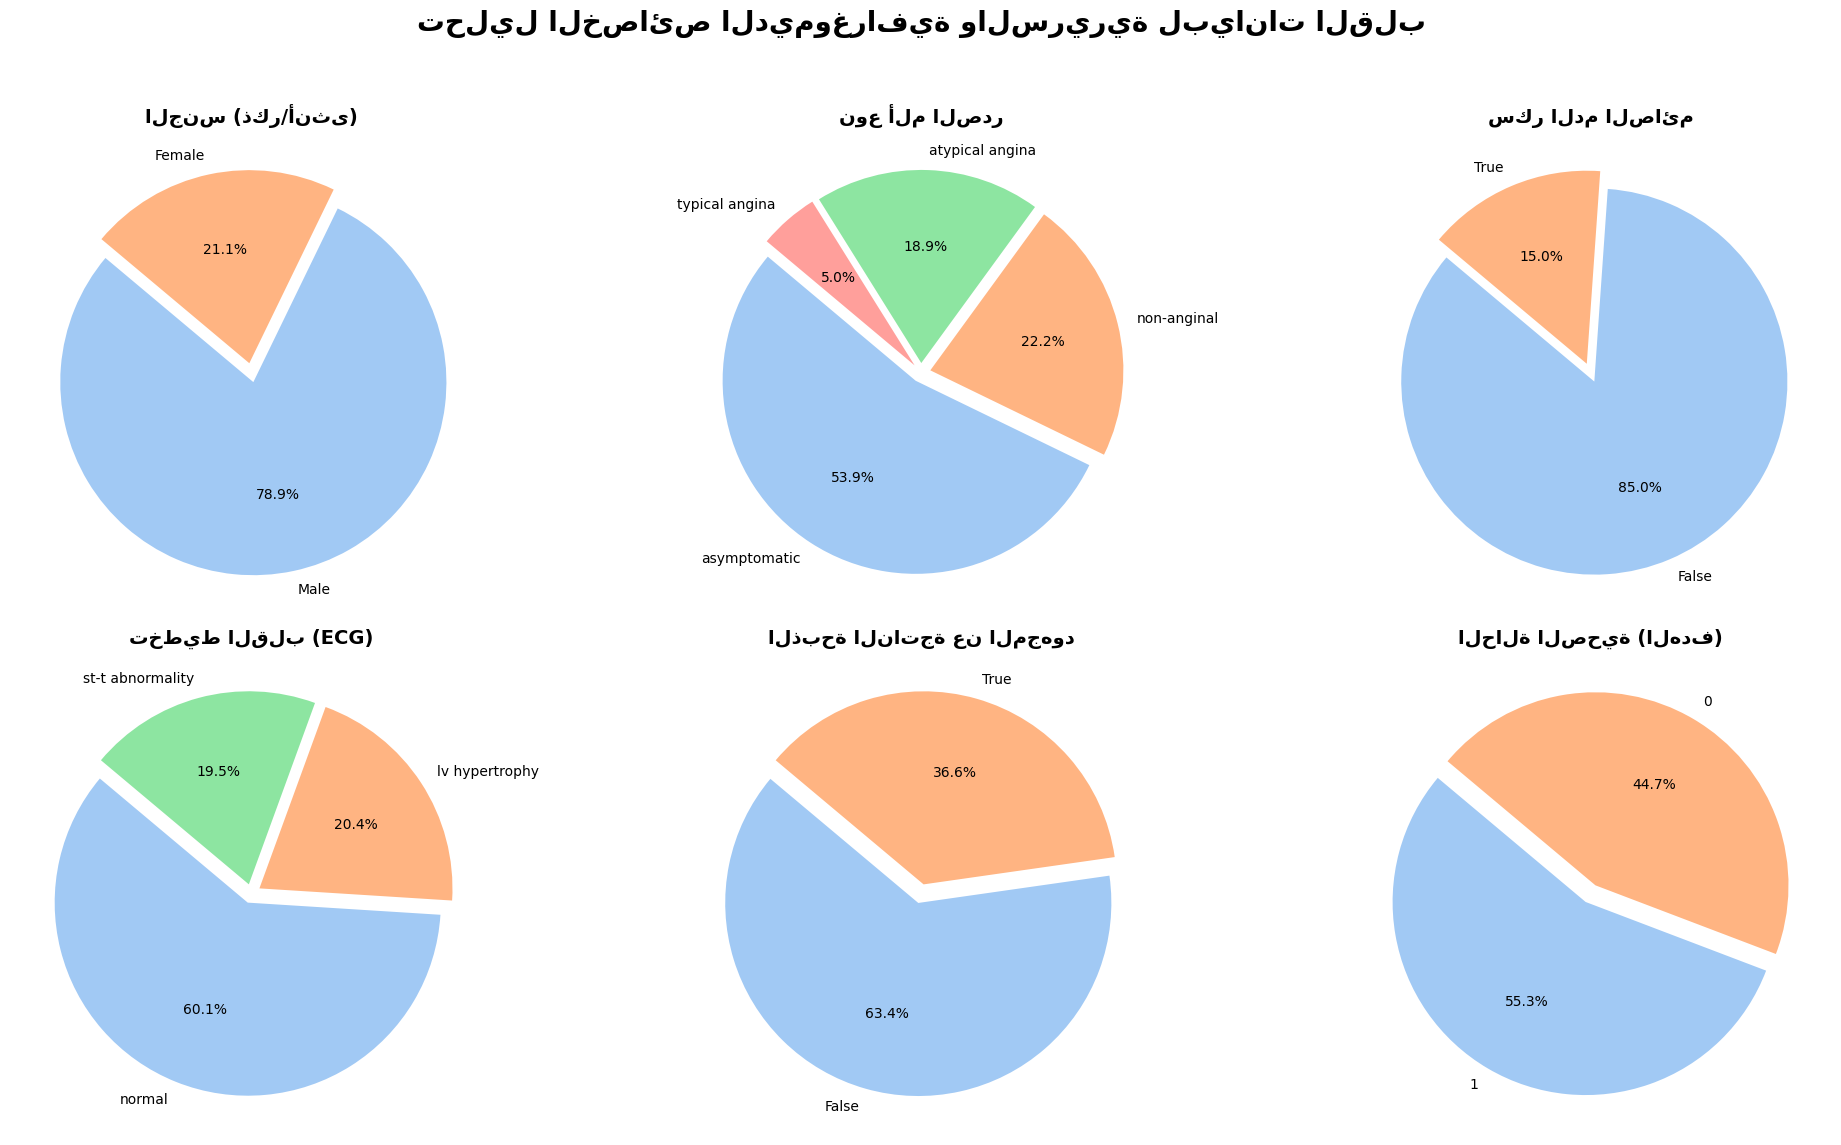

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Data Preprocessing (from Mt-zsiXCSj0z) ---

# 1. تعبئة القيم المفقودة في الأعمدة الرقمية بالوسيط (Median)
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. تعبئة القيم المفقودة في الأعمدة التصنيفية بالقيمة الأكثر تكراراً (Mode)
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. التأكد مرة أخرى من نظافة البيانات (Optional, but good for verification)
print("\n--- فحص البيانات بعد التنظيف ---")
print(df.isnull().sum())

# 4. تحويل العمود المستهدف (num) إلى تصنيف ثنائي (0 أو 1)
# في هذه البيانات: 0 يعني سليم، وأي رقم آخر (1,2,3,4) يعني وجود إصابة
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# حذف الأعمدة التي لم نعد نحتاجها (مثل id والعمود القديم num)
df = df.drop(['id', 'dataset', 'num'], axis=1)

print("\nتم تجهيز البيانات بنجاح!")
print(df.head())

# --- Plotting Code (from lmm9qo_Gfxj3) ---

# إعداد شكل الشبكة: صفين و3 أعمدة لعرض عدة خصائص مرة واحدة
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('تحليل الخصائص الديموغرافية والسريرية لبيانات القلب', fontsize=20, fontweight='bold')

# قائمة بالخصائص التي نريد تمثيلها دائرياً
features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'target']
titles = ['الجنس (ذكر/أنثى)', 'نوع ألم الصدر', 'سكر الدم الصائم',
          'تخطيط القلب (ECG)', 'الذبحة الناتجة عن المجهود', 'الحالة الصحية (الهدف)']

# الألوان المفضلة للرسوم
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

# حلقة تكرارية لإنشاء الرسوم تلقائياً في الـ subplots
for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    data = df[col].value_counts()
    ax.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140,
           colors=sns.color_palette('pastel'), explode=[0.05]*len(data))
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

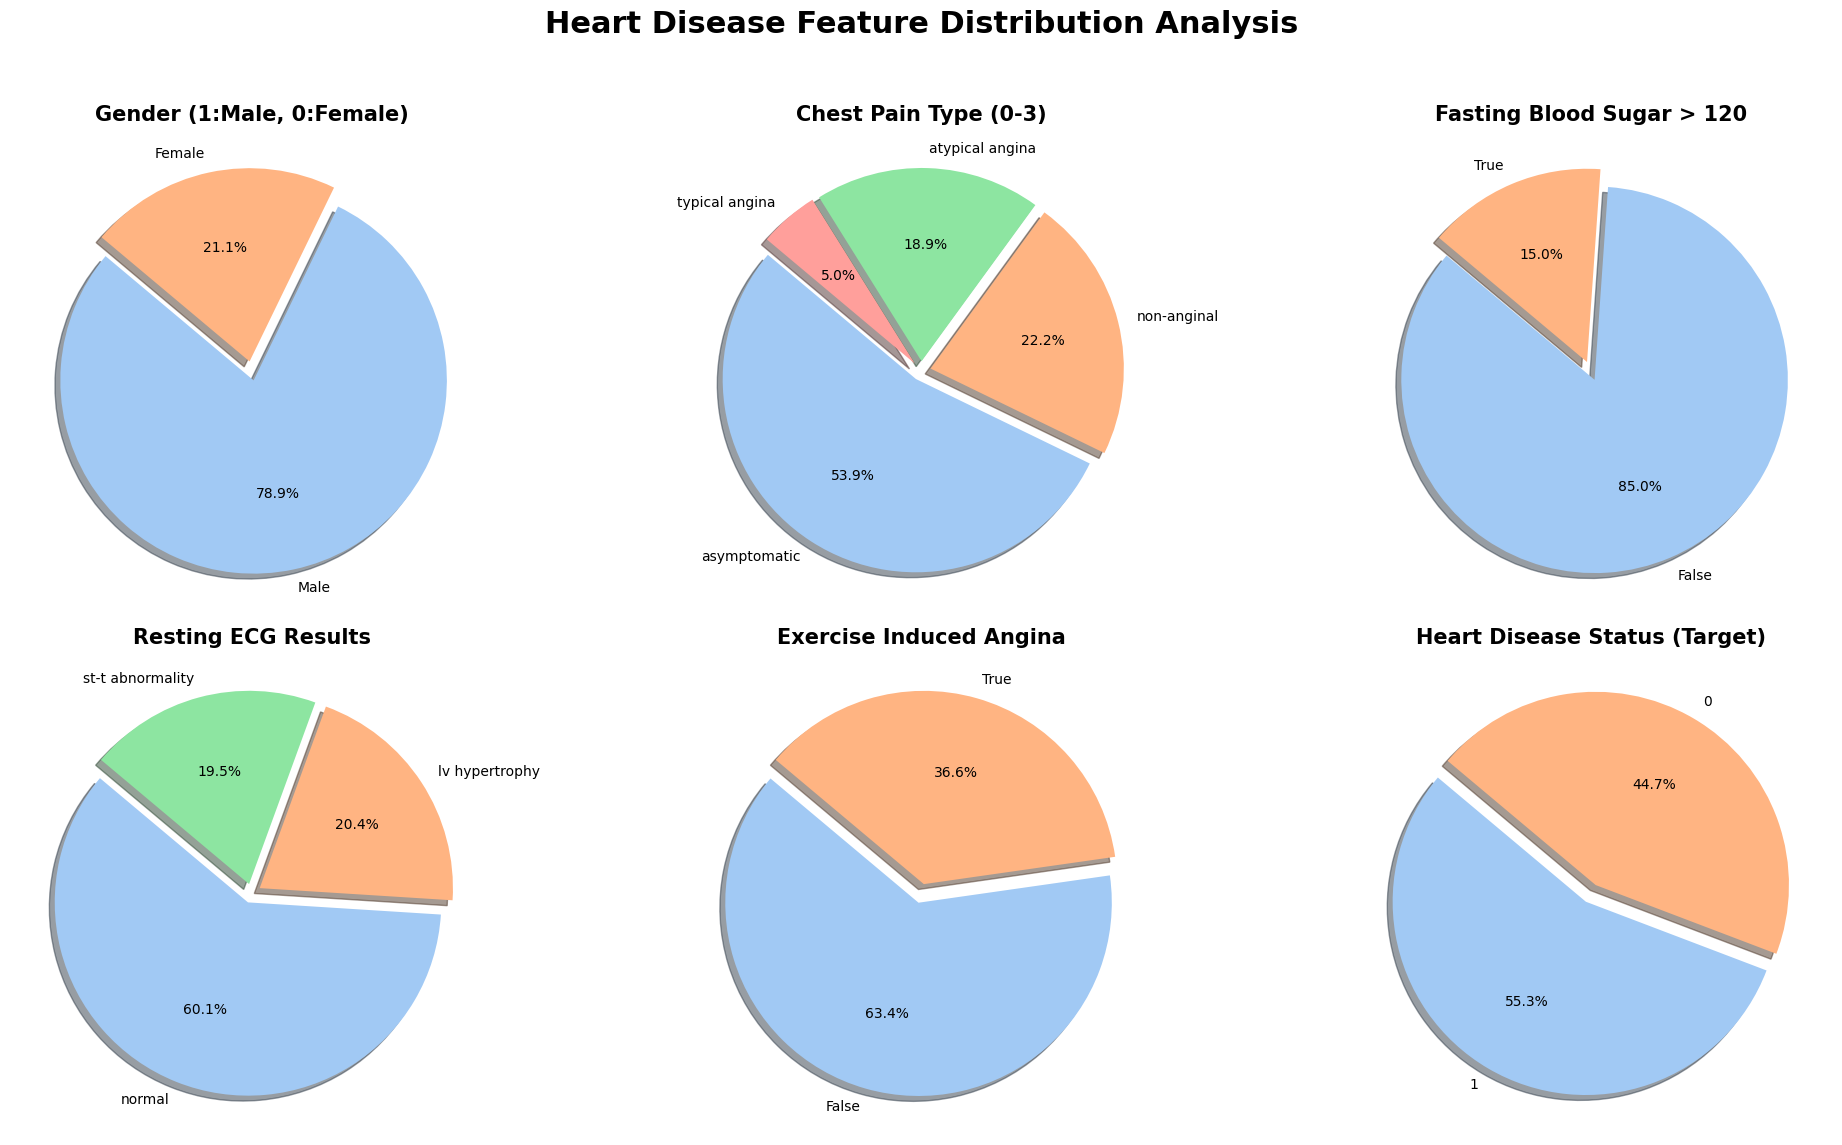

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Heart Disease Feature Distribution Analysis', fontsize=22, fontweight='bold')


features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'target']
titles = ['Gender (1:Male, 0:Female)', 'Chest Pain Type (0-3)', 'Fasting Blood Sugar > 120',
          'Resting ECG Results', 'Exercise Induced Angina', 'Heart Disease Status (Target)']


colors = sns.color_palette('pastel')


for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    data = df[col].value_counts()


    ax.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140,
           colors=colors, explode=[0.05]*len(data), shadow=True)
    ax.set_title(titles[i], fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. تحويل الكلمات (Categorical Data) إلى أرقام
# هذا الكود سيحول 'Male' إلى 1 و 'Female' إلى 0 مثلاً
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. تحديد المدخلات (X) والهدف (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# 3. تقسيم البيانات: 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. توحيد مقاييس البيانات (Scaling)
# مهم جداً للتعلم العميق لأن الأعمار (60) تختلف عن الكوليسترول (200)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("تم تحويل البيانات وتقسيمها بنجاح!")
print(f"حجم بيانات التدريب: {X_train.shape}")

تم تحويل البيانات وتقسيمها بنجاح!
حجم بيانات التدريب: (736, 18)
